# Nepal Tourism Arrival Forecasting
### SARIMA & Ridge Regression Models
**DATA 620 | King's College · Westcliff University**

Authors: Asbina Gurung, Pragya Pradhan, Sneha Sharma

Prof. Pawan Niroula

---
## 0. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from pmdarima import auto_arima

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

DATA_FILE = 'Nepal_Tourism_Modeling_Dataset.xlsx'

In [4]:
!pwd

/Users/pragyapradhan/Downloads


---
## 1. Load Data

In [2]:
# ── SARIMA monthly sheet ──────────────────────────────────────────────────────
sarima_df = pd.read_excel(DATA_FILE, sheet_name='SARIMA_Monthly', header=2)
sarima_df = sarima_df[[
    'Year', 'Month', 'Date (YYYY-MM)',
    'Total_Arrivals', 'Third_Country_Arrivals', 'Indian_Arrivals'
]].dropna(subset=['Year'])
sarima_df['Date'] = pd.to_datetime(sarima_df['Date (YYYY-MM)'])
sarima_df = sarima_df.set_index('Date').sort_index()

# ── Annual LR sheets ──────────────────────────────────────────────────────────
lr_3rd_df = pd.read_excel(DATA_FILE, sheet_name='LR_ThirdCountry_Annual', header=3)
lr_3rd_df = lr_3rd_df.rename(
    columns={'Third_Country_Arrivals (Y)': 'Third_Country_Arrivals'}
).dropna(subset=['Year'])
lr_3rd_df['Year'] = lr_3rd_df['Year'].astype(int)

lr_ind_df = pd.read_excel(DATA_FILE, sheet_name='LR_Indian_Annual', header=3)
lr_ind_df = lr_ind_df.rename(
    columns={'Indian_Arrivals (Y)': 'Indian_Arrivals'}
).dropna(subset=['Year'])
lr_ind_df['Year'] = lr_ind_df['Year'].astype(int)

print('SARIMA monthly rows :', len(sarima_df),
      '|', sarima_df.index[0].date(), '→', sarima_df.index[-1].date())
print('LR Third-Country rows:', len(lr_3rd_df),
      '|', lr_3rd_df['Year'].min(), '→', lr_3rd_df['Year'].max())
print('LR Indian rows       :', len(lr_ind_df),
      '|', lr_ind_df['Year'].min(), '→', lr_ind_df['Year'].max())

SARIMA monthly rows : 192 | 2010-01-01 → 2025-12-01
LR Third-Country rows: 16 | 2010 → 2025
LR Indian rows       : 16 | 2010 → 2025


---
## 2. Helper Functions

In [7]:
def get_metrics(y_true, y_pred):
    """Return R², MAE, RMSE, MAPE for a set of predictions."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'R²': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

def print_metrics(metrics, label=''):
    print(f"{'─'*45}")
    if label:
        print(f"  {label}")
    print(f"  R²       : {metrics['R²']:.4f}")
    print(f"  MAE      : {metrics['MAE']:,.0f}")
    print(f"  RMSE     : {metrics['RMSE']:,.0f}")
    print(f"  MAPE (%) : {metrics['MAPE (%)']:.2f}%")
    print(f"{'─'*45}")

---
## 3. Data Overview

In [4]:
# Sample: last 12 months of monthly data
print('=== SARIMA Monthly Dataset (last 12 months) ===')
display(
    sarima_df.reset_index()[[
        'Date', 'Third_Country_Arrivals', 'Indian_Arrivals', 'Total_Arrivals'
    ]].tail(12).style.format({
        'Third_Country_Arrivals': '{:,.0f}',
        'Indian_Arrivals': '{:,.0f}',
        'Total_Arrivals': '{:,.0f}',
    })
)

=== SARIMA Monthly Dataset (last 12 months) ===


,Date,Third_Country_Arrivals,Indian_Arrivals,Total_Arrivals
180,2025-01-01 00:00:00,"59,504","20,486","79,990"
181,2025-02-01 00:00:00,"79,700","19,885","99,585"
182,2025-03-01 00:00:00,"100,218","21,414","121,632"
183,2025-04-01 00:00:00,"90,554","25,933","116,487"
184,2025-05-01 00:00:00,"58,056","28,160","86,216"
185,2025-06-01 00:00:00,"43,763","32,662","76,425"
186,2025-07-01 00:00:00,"43,041","27,152","70,193"
187,2025-08-01 00:00:00,"53,175","35,506","88,681"
188,2025-09-01 00:00:00,"64,184","15,797","79,981"
189,2025-10-01 00:00:00,"111,143","17,300","128,443"


In [5]:
# Annual summary with YoY growth
summary = lr_3rd_df[['Year']].copy()
summary['Third_Country'] = lr_3rd_df['Third_Country_Arrivals'].astype(int)
summary['Indian']        = lr_ind_df['Indian_Arrivals'].astype(int)
summary['Total']         = summary['Third_Country'] + summary['Indian']
summary['YoY_Growth_%']  = summary['Total'].pct_change() * 100

print('=== Annual Arrival Summary ===')
display(
    summary.style
    .format({
        'Third_Country': '{:,.0f}',
        'Indian': '{:,.0f}',
        'Total': '{:,.0f}',
        'YoY_Growth_%': '{:.1f}%',
    })
    .background_gradient(subset=['Total'], cmap='Blues')
)

=== Annual Arrival Summary ===


,Year,Third_Country,Indian,Total,YoY_Growth_%
0,2010,"481,969","120,898","602,867",nan%
1,2011,"586,711","149,504","736,215",22.1%
2,2012,"637,277","165,815","803,092",9.1%
3,2013,"616,642","180,974","797,616",-0.7%
4,2014,"654,775","135,343","790,118",-0.9%
5,2015,"464,156","74,814","538,970",-31.8%
6,2016,"634,753","118,249","753,002",39.7%
7,2017,"779,386","160,832","940,218",24.9%
8,2018,"978,749","194,323","1,173,072",24.8%
9,2019,"943,041","254,150","1,197,191",2.1%


---
## 4. Exploratory Data Analysis

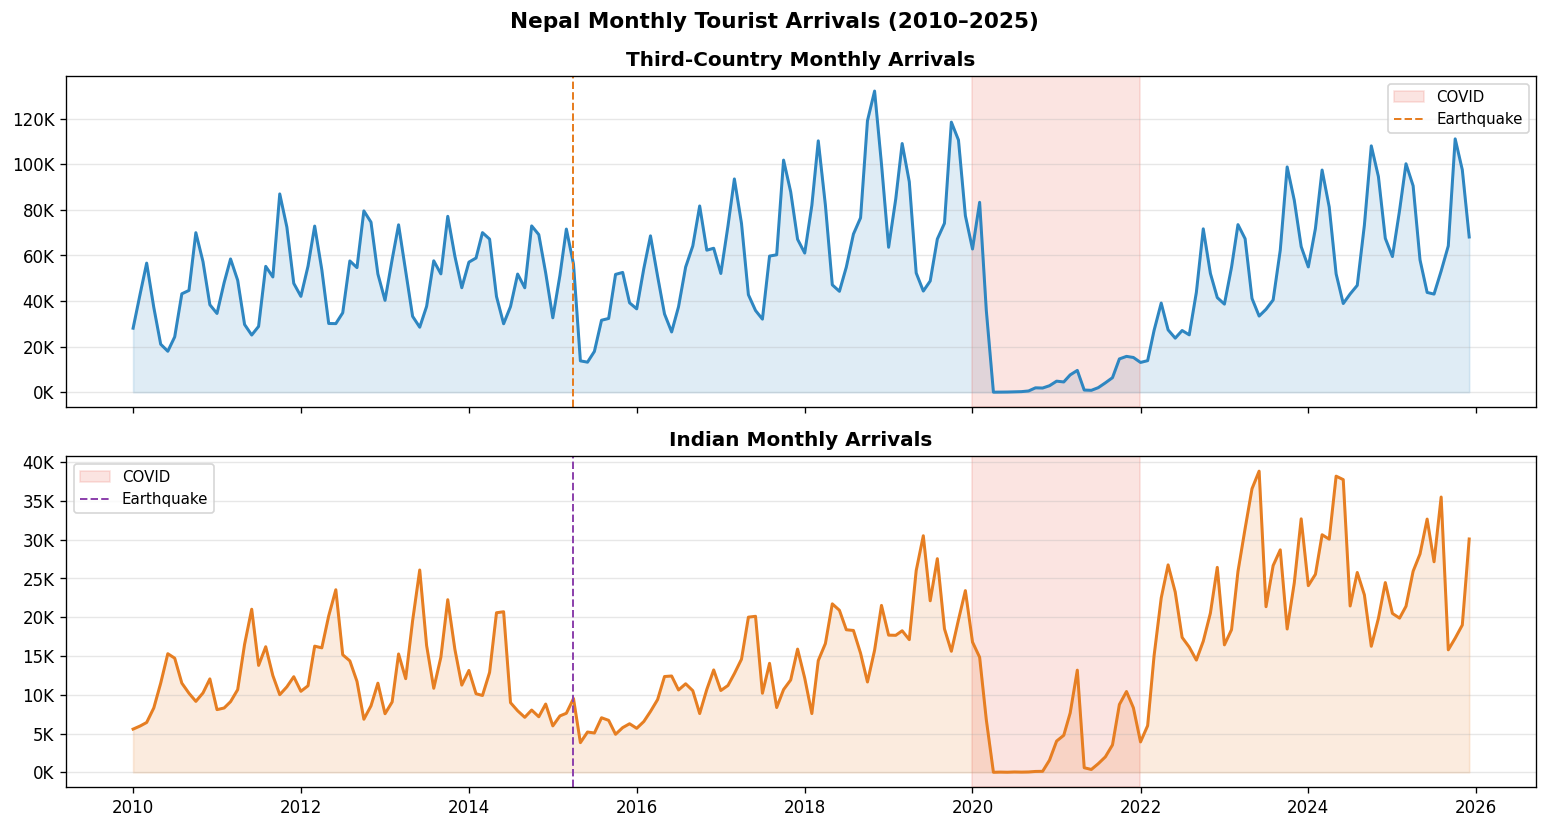

In [6]:
series_3rd = sarima_df['Third_Country_Arrivals'].dropna()
series_ind = sarima_df['Indian_Arrivals'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Third-Country
axes[0].plot(series_3rd.index, series_3rd.values, color='#2E86C1', lw=1.8)
axes[0].fill_between(series_3rd.index, series_3rd.values, alpha=0.15, color='#2E86C1')
axes[0].axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'),
                color='#E74C3C', alpha=0.15, label='COVID')
axes[0].axvline(pd.Timestamp('2015-04-01'), color='#E67E22',
                linestyle='--', lw=1.2, label='Earthquake')
axes[0].set_title('Third-Country Monthly Arrivals', fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

# Indian
axes[1].plot(series_ind.index, series_ind.values, color='#E67E22', lw=1.8)
axes[1].fill_between(series_ind.index, series_ind.values, alpha=0.15, color='#E67E22')
axes[1].axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'),
                color='#E74C3C', alpha=0.15, label='COVID')
axes[1].axvline(pd.Timestamp('2015-04-01'), color='#8E44AD',
                linestyle='--', lw=1.2, label='Earthquake')
axes[1].set_title('Indian Monthly Arrivals', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Nepal Monthly Tourist Arrivals (2010–2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

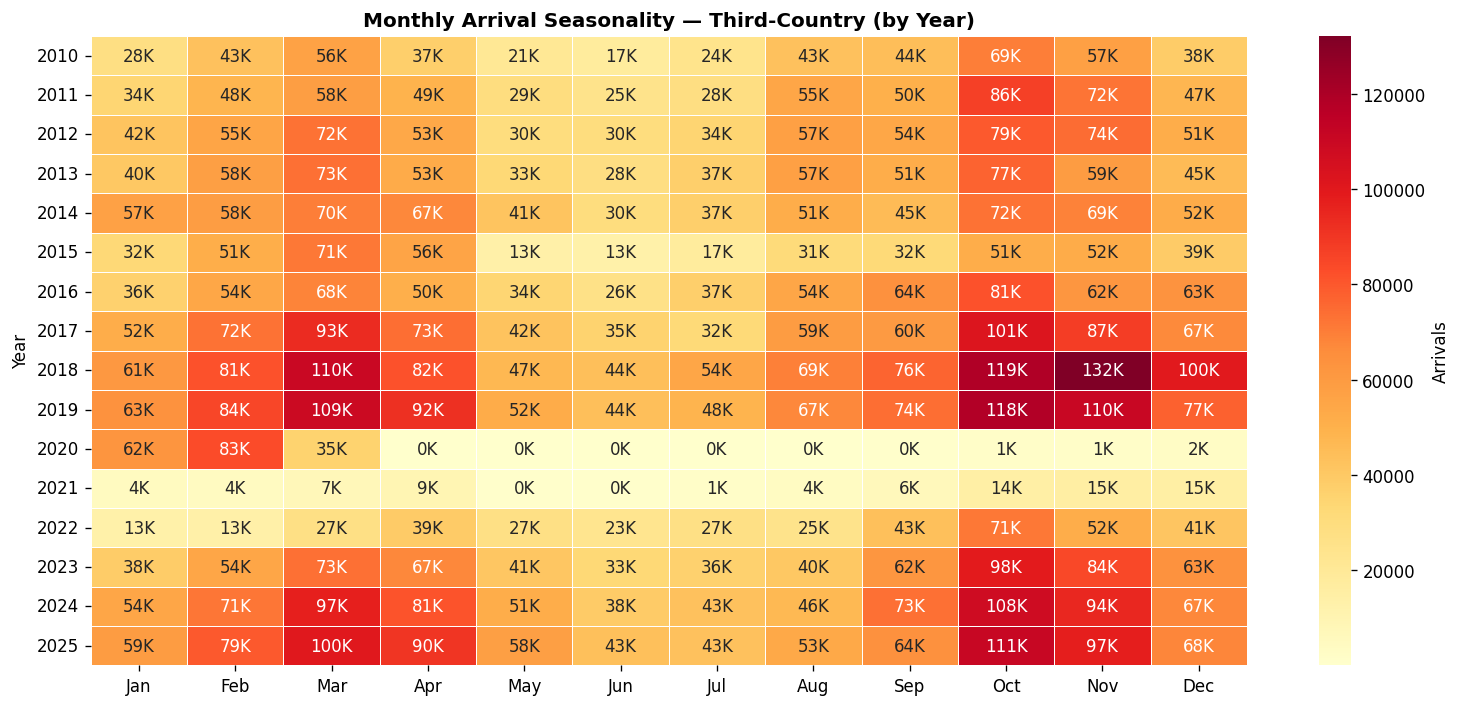

In [8]:
# Seasonality heatmap — Third-Country
pivot = sarima_df[['Third_Country_Arrivals']].copy()
pivot['Year']  = pivot.index.year
pivot['Month'] = pivot.index.month
heat = pivot.pivot_table(
    values='Third_Country_Arrivals', index='Year', columns='Month', aggfunc='sum'
).astype(float)
heat.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
annot = heat.map(lambda v: f'{int(v/1000)}K' if not pd.isna(v) else '')

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(heat, annot=annot, fmt='', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Arrivals'})
ax.set_title('Monthly Arrival Seasonality — Third-Country (by Year)',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ADF Stationarity Tests
print('=== Augmented Dickey-Fuller Stationarity Tests ===')
for label, series in [('Third-Country', series_3rd), ('Indian', series_ind)]:
    result = adfuller(series)
    stat   = result[0]
    pval   = result[1]
    status = 'STATIONARY ✓' if pval < 0.05 else 'Non-stationary → d=1 needed'
    print(f'\n{label}:')
    print(f'  ADF Statistic : {stat:.4f}')
    print(f'  p-value       : {pval:.4f}')
    print(f'  Result        : {status}')

=== Augmented Dickey-Fuller Stationarity Tests ===

Third-Country:
  ADF Statistic : -3.2908
  p-value       : 0.0153
  Result        : STATIONARY ✓

Indian:
  ADF Statistic : -2.3634
  p-value       : 0.1523
  Result        : Non-stationary → d=1 needed


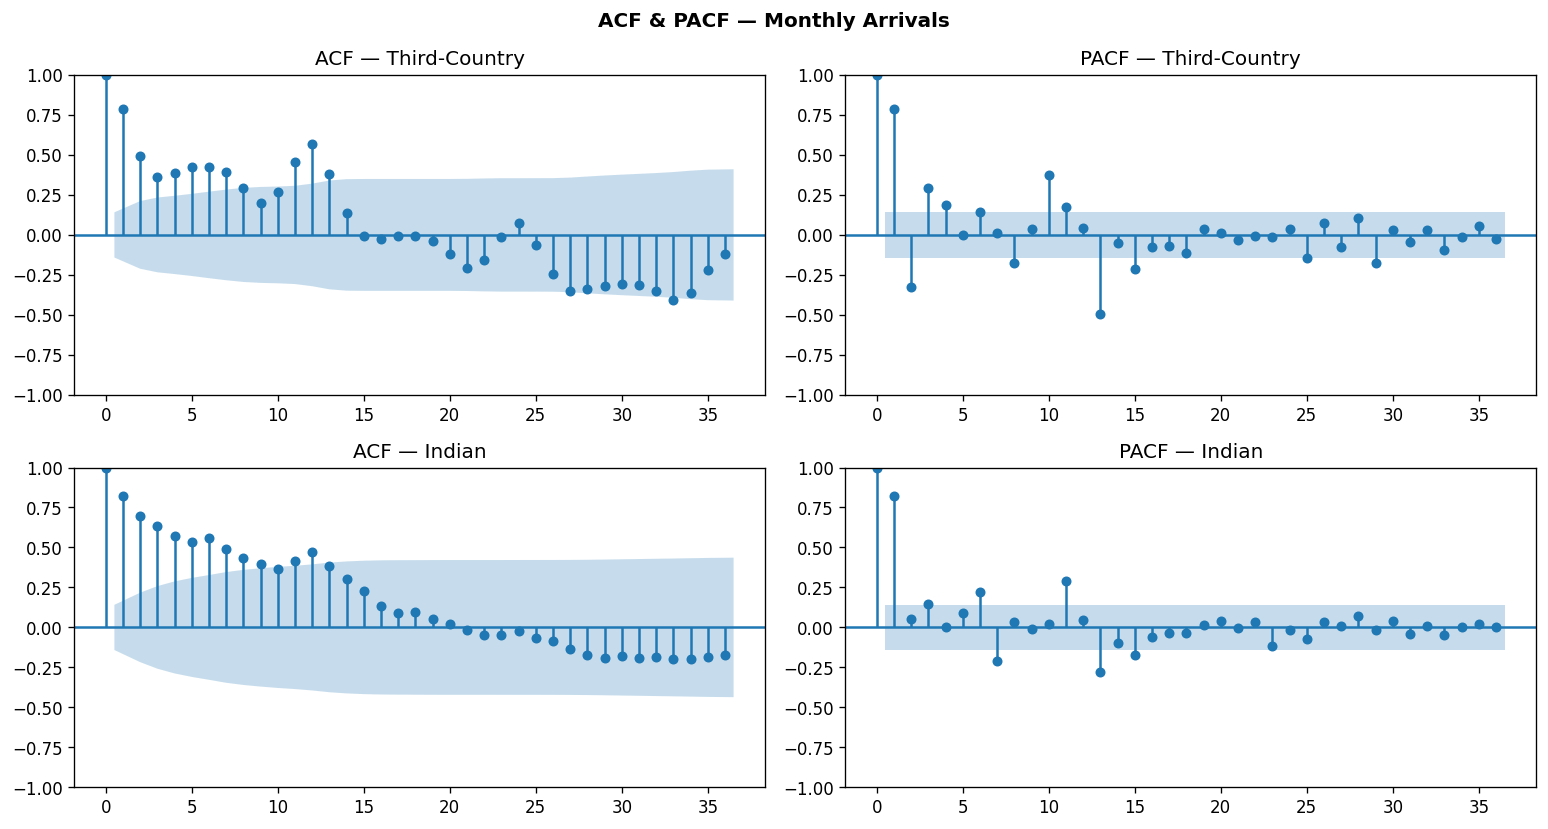

In [10]:
# ACF & PACF plots
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
plot_acf( series_3rd, lags=36, ax=axes[0][0], title='ACF — Third-Country')
plot_pacf(series_3rd, lags=36, ax=axes[0][1], title='PACF — Third-Country')
plot_acf( series_ind, lags=36, ax=axes[1][0], title='ACF — Indian')
plot_pacf(series_ind, lags=36, ax=axes[1][1], title='PACF — Indian')
plt.suptitle('ACF & PACF — Monthly Arrivals', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. SARIMA Models

- `d=1` forced for both models based on ADF results
- `auto_arima` selects optimal `(p,d,q)(P,D,Q,12)` via AIC
- Test set = last 12 months of training data
- Forecast horizon = **24 months** (adjust `FORECAST_MONTHS` below)

In [11]:
FORECAST_MONTHS = 24  # adjust as needed

### 5.1 SARIMA — Third-Country Arrivals

In [12]:
train_3rd = series_3rd.iloc[:-12]
test_3rd  = series_3rd.iloc[-12:]

auto_3rd = auto_arima(
    train_3rd, seasonal=True, m=12, d=1, D=1,
    stepwise=True, information_criterion='aic',
    error_action='ignore', suppress_warnings=True, trace=False
)
order_3rd   = auto_3rd.order
s_order_3rd = auto_3rd.seasonal_order
print(f'Best order  : ARIMA{order_3rd}')
print(f'Seasonal    : {s_order_3rd}')

# Fit on training set for evaluation
res_3rd = SARIMAX(
    train_3rd, order=order_3rd, seasonal_order=s_order_3rd,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)
print(f'Training AIC: {res_3rd.aic:.2f}')

# Test forecast
fc_test_3rd       = res_3rd.get_forecast(steps=12)
pred_test_3rd     = fc_test_3rd.predicted_mean
pred_test_3rd.index = test_3rd.index

print('\nTest Metrics (last 12 months):')
m3rd = get_metrics(test_3rd.values, pred_test_3rd.values)
print_metrics(m3rd, 'SARIMA Third-Country')

Best order  : ARIMA(2, 1, 0)
Seasonal    : (0, 1, 2, 12)


/Users/pragyapradhan/Library/Python/3.14/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/pragyapradhan/Library/Python/3.14/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Training AIC: 3067.69

Test Metrics (last 12 months):
─────────────────────────────────────────────
  SARIMA Third-Country
  R²       : 0.9016
  MAE      : 5,898
  RMSE     : 6,895
  MAPE (%) : 9.22%
─────────────────────────────────────────────


/Users/pragyapradhan/Library/Python/3.14/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/pragyapradhan/Library/Python/3.14/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


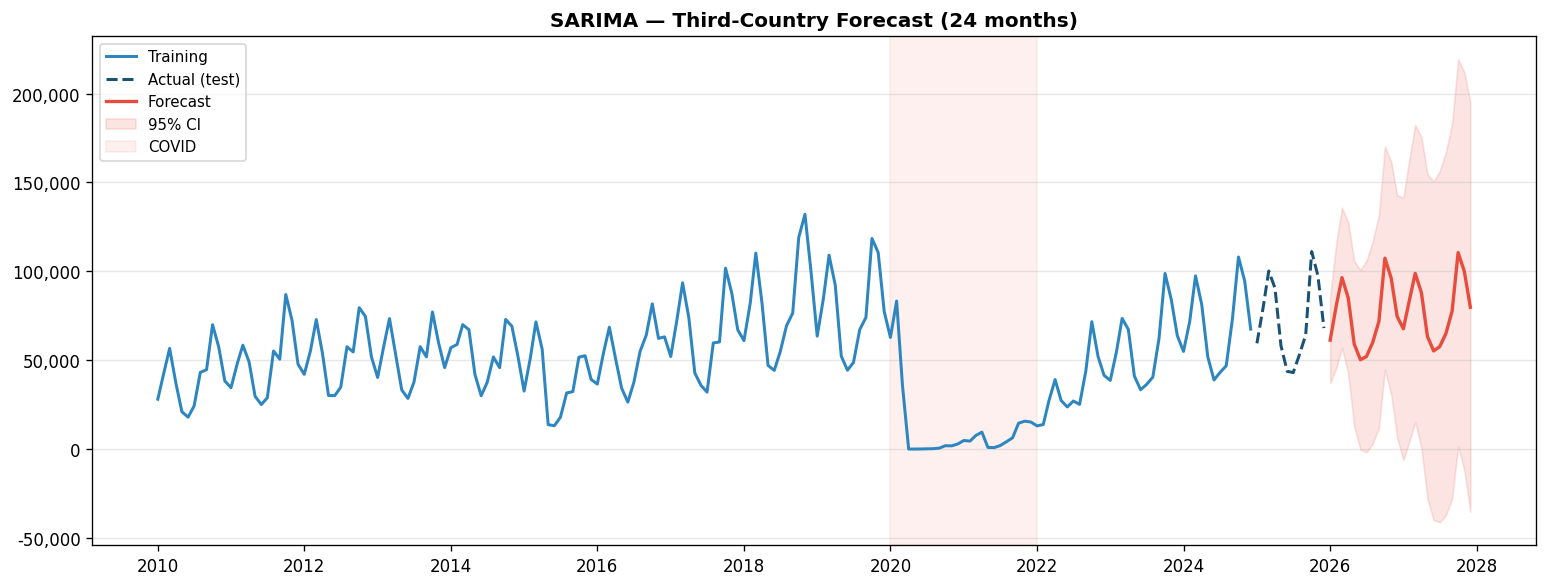

In [13]:
# Refit on full series for future forecast
res_full_3rd    = SARIMAX(
    series_3rd, order=order_3rd, seasonal_order=s_order_3rd,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)
fc_future_3rd   = res_full_3rd.get_forecast(steps=FORECAST_MONTHS)
pred_future_3rd = fc_future_3rd.predicted_mean
ci_future_3rd   = fc_future_3rd.conf_int()

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train_3rd.index, train_3rd.values,
        color='#2E86C1', lw=1.8, label='Training')
ax.plot(test_3rd.index, test_3rd.values,
        color='#1A5276', lw=1.8, linestyle='--', label='Actual (test)')
ax.plot(pred_future_3rd.index, pred_future_3rd.values,
        color='#E74C3C', lw=2, label='Forecast')
ax.fill_between(pred_future_3rd.index,
                ci_future_3rd.iloc[:, 0], ci_future_3rd.iloc[:, 1],
                color='#E74C3C', alpha=0.15, label='95% CI')
ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'),
           color='#E74C3C', alpha=0.08, label='COVID')
ax.set_title(f'SARIMA — Third-Country Forecast ({FORECAST_MONTHS} months)',
             fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Forecast table
fc_table_3rd = pd.DataFrame({
    'Month'       : pred_future_3rd.index.strftime('%Y-%m'),
    'Forecast'    : pred_future_3rd.values.round(0).astype(int),
    'Lower 95% CI': ci_future_3rd.iloc[:, 0].round(0).astype(int),
    'Upper 95% CI': ci_future_3rd.iloc[:, 1].round(0).astype(int),
})
display(
    fc_table_3rd.style.format({
        'Forecast': '{:,}', 'Lower 95% CI': '{:,}', 'Upper 95% CI': '{:,}'
    })
)

,Month,Forecast,Lower 95% CI,Upper 95% CI
2026-01-01 00:00:00,2026-01,"61,274","37,152","85,396"
2026-02-01 00:00:00,2026-02,"80,997","45,621","116,374"
2026-03-01 00:00:00,2026-03,"96,467","57,111","135,823"
2026-04-01 00:00:00,2026-04,"85,116","42,640","127,591"
2026-05-01 00:00:00,2026-05,"59,076","12,536","105,617"
2026-06-01 00:00:00,2026-06,"50,274",-265,"100,813"
2026-07-01 00:00:00,2026-07,"52,086","-1,783","105,956"
2026-08-01 00:00:00,2026-08,"59,952","3,051","116,853"
2026-09-01 00:00:00,2026-09,"71,806","11,917","131,696"
2026-10-01 00:00:00,2026-10,"107,395","44,616","170,174"


### 5.2 SARIMA — Indian Arrivals

> ⚠️ COVID years (2020–2021) are excluded from training. Post-COVID Indian arrivals surged beyond historical training range — model accuracy is limited.

In [15]:
series_ind_clean = series_ind[~series_ind.index.year.isin([2020, 2021])]
train_ind = series_ind_clean.iloc[:-12]
test_ind  = series_ind_clean.iloc[-12:]

auto_ind = auto_arima(
    train_ind, seasonal=True, m=12, d=1, D=1,
    stepwise=True, information_criterion='aic',
    error_action='ignore', suppress_warnings=True, trace=False
)
order_ind   = auto_ind.order
s_order_ind = auto_ind.seasonal_order
print(f'Best order  : ARIMA{order_ind}')
print(f'Seasonal    : {s_order_ind}')

res_ind = SARIMAX(
    train_ind, order=order_ind, seasonal_order=s_order_ind,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)
print(f'Training AIC: {res_ind.aic:.2f}')

fc_test_ind       = res_ind.get_forecast(steps=12)
pred_test_ind     = fc_test_ind.predicted_mean
pred_test_ind.index = test_ind.index

print('\nTest Metrics (last 12 months, excl. COVID):')
mind = get_metrics(test_ind.values, pred_test_ind.values)
print_metrics(mind, 'SARIMA Indian')

Best order  : ARIMA(0, 1, 2)
Seasonal    : (0, 1, 1, 12)
Training AIC: 2478.72

Test Metrics (last 12 months, excl. COVID):
─────────────────────────────────────────────
  SARIMA Indian
  R²       : 0.4314
  MAE      : 3,586
  RMSE     : 4,599
  MAPE (%) : 14.92%
─────────────────────────────────────────────


/Users/pragyapradhan/Library/Python/3.14/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pragyapradhan/Library/Python/3.14/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pragyapradhan/Library/Python/3.14/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


/Users/pragyapradhan/Library/Python/3.14/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/pragyapradhan/Library/Python/3.14/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


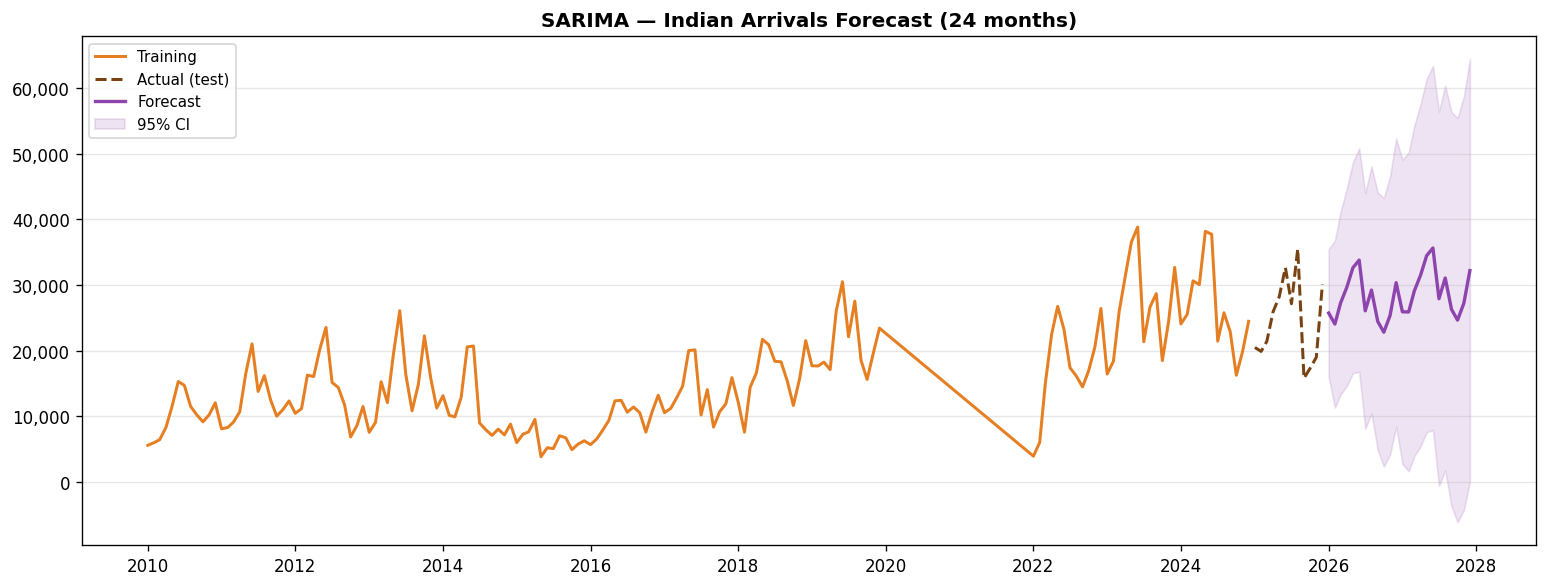

In [16]:
# Refit on full series
res_full_ind    = SARIMAX(
    series_ind, order=order_ind, seasonal_order=s_order_ind,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)
fc_future_ind   = res_full_ind.get_forecast(steps=FORECAST_MONTHS)
pred_future_ind = fc_future_ind.predicted_mean
ci_future_ind   = fc_future_ind.conf_int()

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train_ind.index, train_ind.values,
        color='#E67E22', lw=1.8, label='Training')
ax.plot(test_ind.index, test_ind.values,
        color='#784212', lw=1.8, linestyle='--', label='Actual (test)')
ax.plot(pred_future_ind.index, pred_future_ind.values,
        color='#8E44AD', lw=2, label='Forecast')
ax.fill_between(pred_future_ind.index,
                ci_future_ind.iloc[:, 0], ci_future_ind.iloc[:, 1],
                color='#8E44AD', alpha=0.15, label='95% CI')
ax.set_title(f'SARIMA — Indian Arrivals Forecast ({FORECAST_MONTHS} months)',
             fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Forecast table
fc_table_ind = pd.DataFrame({
    'Month'       : pred_future_ind.index.strftime('%Y-%m'),
    'Forecast'    : pred_future_ind.values.round(0).astype(int),
    'Lower 95% CI': ci_future_ind.iloc[:, 0].round(0).astype(int),
    'Upper 95% CI': ci_future_ind.iloc[:, 1].round(0).astype(int),
})
display(
    fc_table_ind.style.format({
        'Forecast': '{:,}', 'Lower 95% CI': '{:,}', 'Upper 95% CI': '{:,}'
    })
)

,Month,Forecast,Lower 95% CI,Upper 95% CI
2026-01-01 00:00:00,2026-01,"25,738","16,012","35,463"
2026-02-01 00:00:00,2026-02,"24,057","11,314","36,800"
2026-03-01 00:00:00,2026-03,"27,261","13,318","41,204"
2026-04-01 00:00:00,2026-04,"29,675","14,628","44,722"
2026-05-01 00:00:00,2026-05,"32,637","16,561","48,713"
2026-06-01 00:00:00,2026-06,"33,807","16,764","50,850"
2026-07-01 00:00:00,2026-07,"26,073","8,115","44,031"
2026-08-01 00:00:00,2026-08,"29,238","10,409","48,066"
2026-09-01 00:00:00,2026-09,"24,452","4,792","44,112"
2026-10-01 00:00:00,2026-10,"22,814","2,356","43,273"


---
## 6. Ridge Regression Models

Ridge is used instead of OLS to handle multicollinearity in the small annual dataset (~16 rows). Features are standardized; regularization alpha is chosen by 5-fold cross-validation.

**Feature flags** — set `True/False` to include/exclude:

In [18]:
# ── Feature flags ─────────────────────────────────────────────────────────────
# Third-Country
USE_TREKKING = True
USE_LAG1_3RD = True
USE_LAG2_3RD = True
USE_INCOME   = False
USE_LOS      = False

# Indian
USE_PILGRIMAGE = True
USE_LAG1_IND   = True
USE_HOLIDAY    = False

# Model settings
N_TEST_YEARS  = 3
FORECAST_YEARS = 3

# Build feature lists
features_3rd = []
if USE_TREKKING: features_3rd.append('Trekking_Mtn_Arrivals')
if USE_LAG1_3RD: features_3rd.append('Lag1_Third_Country')
if USE_LAG2_3RD: features_3rd.append('Lag2_Third_Country')
if USE_INCOME:   features_3rd.append('Tourism_Income_USD_Mn')
if USE_LOS:      features_3rd.append('Avg_Length_of_Stay')
features_3rd += ['COVID_Dummy', 'Earthquake_Dummy']

features_ind = []
if USE_PILGRIMAGE: features_ind.append('Pilgrimage_Arrivals')
if USE_LAG1_IND:   features_ind.append('Lag1_Indian')
if USE_HOLIDAY:    features_ind.append('Holiday_Arrivals')
features_ind += ['COVID_Dummy', 'Earthquake_Dummy']

print('Third-Country features:', features_3rd)
print('Indian features        :', features_ind)

Third-Country features: ['Trekking_Mtn_Arrivals', 'Lag1_Third_Country', 'Lag2_Third_Country', 'COVID_Dummy', 'Earthquake_Dummy']
Indian features        : ['Pilgrimage_Arrivals', 'Lag1_Indian', 'COVID_Dummy', 'Earthquake_Dummy']


### 6.1 Ridge LR — Third-Country Arrivals

In [19]:
sub_3rd = lr_3rd_df[['Year', 'Third_Country_Arrivals'] + features_3rd].dropna()
X_3rd   = sub_3rd[features_3rd].values
y_3rd   = sub_3rd['Third_Country_Arrivals'].values
yrs_3rd = sub_3rd['Year'].values
sp3     = len(sub_3rd) - N_TEST_YEARS

sc3   = StandardScaler()
Xsc3  = sc3.fit_transform(X_3rd)
ridge3 = RidgeCV(alphas=[0.01, 0.1, 1, 5, 10, 50, 100, 500, 1000], cv=5)
ridge3.fit(Xsc3[:sp3], y_3rd[:sp3])

yptr3  = ridge3.predict(Xsc3[:sp3])
ypte3  = ridge3.predict(Xsc3[sp3:])

print(f'Best alpha  : {ridge3.alpha_:.2f}')
print(f'Train period: {yrs_3rd[0]}–{yrs_3rd[sp3-1]}')
print(f'Test period : {yrs_3rd[sp3]}–{yrs_3rd[-1]}')

m3_train = get_metrics(y_3rd[:sp3], yptr3)
m3_test  = get_metrics(y_3rd[sp3:], ypte3)
print_metrics(m3_train, 'Train Performance')
print_metrics(m3_test,  'Test Performance')

Best alpha  : 1.00
Train period: 2010–2022
Test period : 2023–2025
─────────────────────────────────────────────
  Train Performance
  R²       : 0.9311
  MAE      : 50,706
  RMSE     : 64,845
  MAPE (%) : 11.36%
─────────────────────────────────────────────
─────────────────────────────────────────────
  Test Performance
  R²       : 0.9726
  MAE      : 10,994
  RMSE     : 12,342
  MAPE (%) : 1.35%
─────────────────────────────────────────────


In [20]:
# Future forecast (recursive, using predicted values as lag inputs)
prev1_3  = float(y_3rd[-1])
prev2_3  = float(y_3rd[-2])
trek_last = float(sub_3rd['Trekking_Mtn_Arrivals'].iloc[-1]) if USE_TREKKING else 0
inc_last  = float(sub_3rd['Tourism_Income_USD_Mn'].iloc[-1]) if USE_INCOME else 0
los_last  = float(sub_3rd['Avg_Length_of_Stay'].iloc[-1]) if USE_LOS else 0

fut_yrs3, fut_preds3 = [], []
for i in range(1, FORECAST_YEARS + 1):
    row_d = {}
    if USE_TREKKING: row_d['Trekking_Mtn_Arrivals'] = trek_last
    if USE_LAG1_3RD: row_d['Lag1_Third_Country']    = prev1_3
    if USE_LAG2_3RD: row_d['Lag2_Third_Country']    = prev2_3
    if USE_INCOME:   row_d['Tourism_Income_USD_Mn'] = inc_last
    if USE_LOS:      row_d['Avg_Length_of_Stay']    = los_last
    row_d['COVID_Dummy'] = 0
    row_d['Earthquake_Dummy'] = 0
    row_arr = np.array([[row_d[f] for f in features_3rd]])
    pred = ridge3.predict(sc3.transform(row_arr))[0]
    fut_yrs3.append(int(yrs_3rd[-1]) + i)
    fut_preds3.append(pred)
    prev2_3 = prev1_3
    prev1_3 = pred

print('\nFuture Forecast (Third-Country):')
for yr, pred in zip(fut_yrs3, fut_preds3):
    print(f'  {yr}: {int(pred):,}')


Future Forecast (Third-Country):
  2026: 878,496
  2027: 883,565
  2028: 885,383


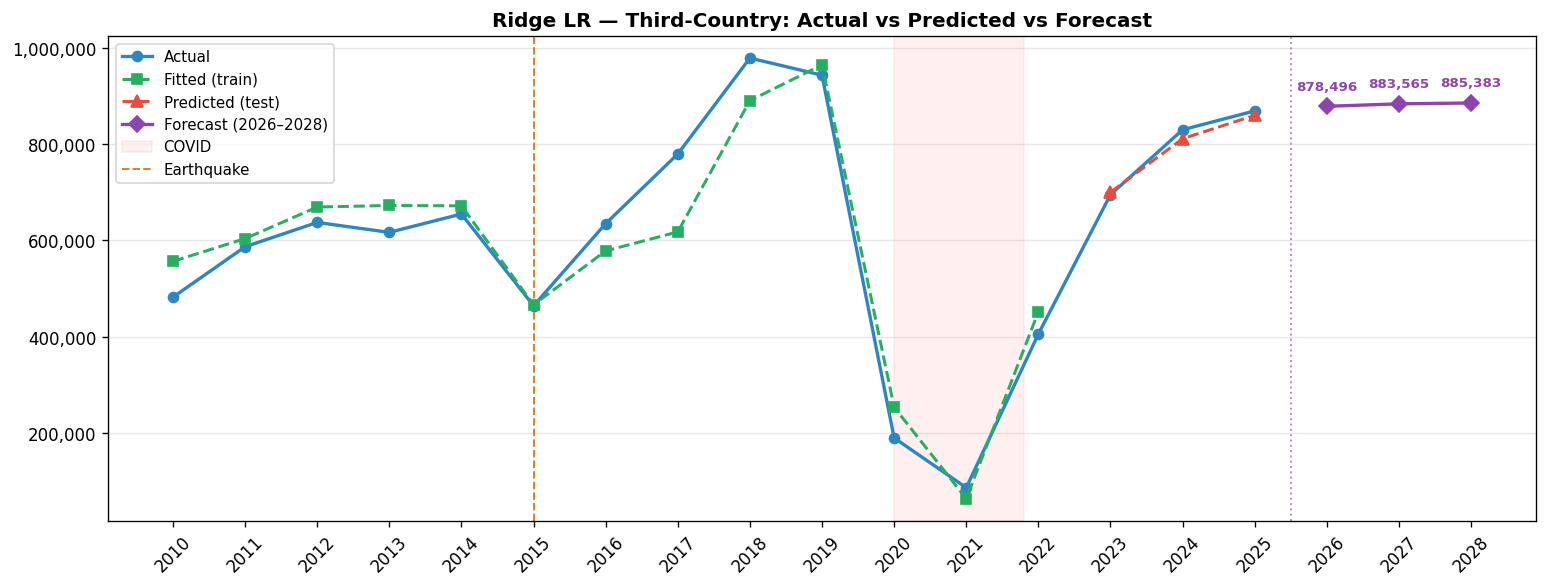

In [21]:
# Plot — Actual vs Fitted vs Forecast
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(yrs_3rd, y_3rd, 'o-', color='#2E86C1', lw=2, markersize=6,
        label='Actual', zorder=3)
ax.plot(yrs_3rd[:sp3], yptr3, 's--', color='#27AE60', lw=1.8, markersize=6,
        label='Fitted (train)', zorder=3)
ax.plot(yrs_3rd[sp3:], ypte3, '^--', color='#E74C3C', lw=1.8, markersize=7,
        label='Predicted (test)', zorder=3)
ax.plot(fut_yrs3, fut_preds3, 'D-', color='#8E44AD', lw=2, markersize=7,
        label=f'Forecast ({fut_yrs3[0]}–{fut_yrs3[-1]})', zorder=3)
for yr, pred in zip(fut_yrs3, fut_preds3):
    ax.annotate(f'{int(pred):,}', xy=(yr, pred), xytext=(0, 10),
                textcoords='offset points', ha='center',
                fontsize=8, color='#8E44AD', fontweight='bold')
ax.axvspan(2020, 2021.8, color='#E74C3C', alpha=0.08, label='COVID')
ax.axvline(2015, color='#E67E22', linestyle='--', lw=1.2, label='Earthquake')
ax.axvline(yrs_3rd[-1] + 0.5, color='#8E44AD', linestyle=':', lw=1.2, alpha=0.6)
ax.set_title('Ridge LR — Third-Country: Actual vs Predicted vs Forecast',
             fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(range(int(yrs_3rd[0]), fut_yrs3[-1] + 1))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9, loc='upper left'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

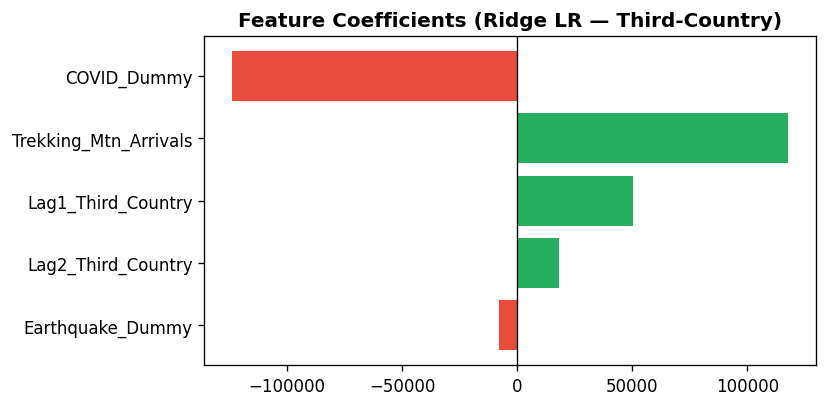

,Feature,Coefficient
4,Earthquake_Dummy,-8031.33
2,Lag2_Third_Country,17940.63
1,Lag1_Third_Country,50433.80
0,Trekking_Mtn_Arrivals,117734.20
3,COVID_Dummy,-123949.93


In [22]:
# Feature coefficients
coef_df3 = pd.DataFrame({
    'Feature'    : features_3rd,
    'Coefficient': ridge3.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ['#E74C3C' if c < 0 else '#27AE60' for c in coef_df3['Coefficient']]
ax.barh(coef_df3['Feature'], coef_df3['Coefficient'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature Coefficients (Ridge LR — Third-Country)', fontweight='bold')
plt.tight_layout()
plt.show()

display(coef_df3.style.format({'Coefficient': '{:.2f}'}))

### 6.2 Ridge LR — Indian Arrivals

> ⚠️ Post-COVID Indian arrivals (2023–2025: 319K–438K) exceed training maximum (254K in 2019). Model is retained for structural coefficient interpretation only. Use SARIMA for Indian forecasting.

In [23]:
sub_ind = lr_ind_df[['Year', 'Indian_Arrivals'] + features_ind].dropna()
X_ind   = sub_ind[features_ind].values
y_ind   = sub_ind['Indian_Arrivals'].values
yrs_ind = sub_ind['Year'].values
spi     = len(sub_ind) - N_TEST_YEARS

sci    = StandardScaler()
Xsci   = sci.fit_transform(X_ind)
ridgei = RidgeCV(alphas=[0.01, 0.1, 1, 5, 10, 50, 100, 500, 1000], cv=5)
ridgei.fit(Xsci[:spi], y_ind[:spi])

yptri  = ridgei.predict(Xsci[:spi])
yptei  = ridgei.predict(Xsci[spi:])

print(f'Best alpha  : {ridgei.alpha_:.2f}')
mi_train = get_metrics(y_ind[:spi], yptri)
mi_test  = get_metrics(y_ind[spi:], yptei)
print_metrics(mi_train, 'Train Performance')
print_metrics(mi_test,  'Test Performance (NOTE: structural break expected)')

Best alpha  : 10.00
─────────────────────────────────────────────
  Train Performance
  R²       : 0.6255
  MAE      : 29,058
  RMSE     : 35,679
  MAPE (%) : 25.99%
─────────────────────────────────────────────
─────────────────────────────────────────────
  Test Performance (NOTE: structural break expected)
  R²       : -122.2492
  MAE      : 132,785
  RMSE     : 133,676
  MAPE (%) : 42.66%
─────────────────────────────────────────────


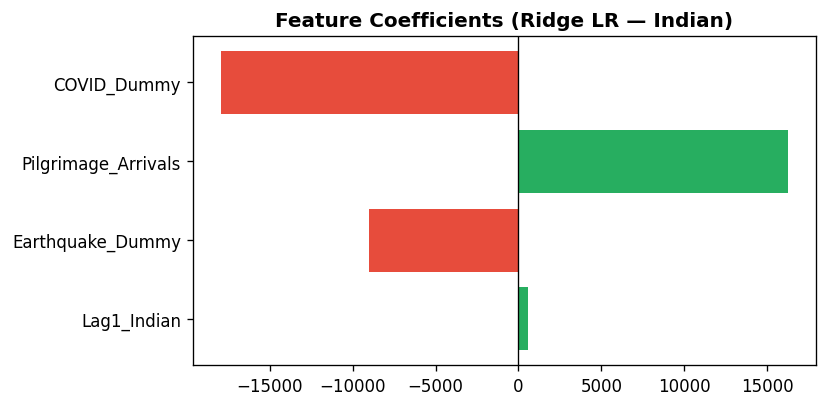

,Feature,Coefficient
1,Lag1_Indian,574.33
3,Earthquake_Dummy,-9010.85
0,Pilgrimage_Arrivals,16250.29
2,COVID_Dummy,-17952.38


In [24]:
# Feature coefficients
coef_dfi = pd.DataFrame({
    'Feature'    : features_ind,
    'Coefficient': ridgei.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ['#E74C3C' if c < 0 else '#27AE60' for c in coef_dfi['Coefficient']]
ax.barh(coef_dfi['Feature'], coef_dfi['Coefficient'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature Coefficients (Ridge LR — Indian)', fontweight='bold')
plt.tight_layout()
plt.show()

display(coef_dfi.style.format({'Coefficient': '{:.2f}'}))

---
## 7. Model Comparison

In [25]:
summary_data = {
    'Model'    : ['SARIMA Third-Country', 'SARIMA Indian',
                  'Ridge LR Third-Country', 'Ridge LR Indian'],
    'Test R²'  : [m3rd['R²'], mind['R²'], m3_test['R²'], mi_test['R²']],
    'Test MAE' : [m3rd['MAE'], mind['MAE'], m3_test['MAE'], mi_test['MAE']],
    'Test MAPE': [m3rd['MAPE (%)'], mind['MAPE (%)'],
                  m3_test['MAPE (%)'], mi_test['MAPE (%)']],
    'Status'   : [
        '✅ Good'  if m3rd['R²']     >= 0.8 else '⚠️ Moderate',
        '✅ Good'  if mind['R²']     >= 0.8 else '⚠️ Moderate',
        '✅ Good'  if m3_test['R²']  >= 0.8 else '⚠️ Moderate',
        '❌ Structural limitation',
    ]
}
summary_df = pd.DataFrame(summary_data)
display(
    summary_df.style
    .format({'Test R²': '{:.4f}', 'Test MAE': '{:,.0f}', 'Test MAPE': '{:.2f}%'})
    .background_gradient(subset=['Test R²'], cmap='RdYlGn')
)

,Model,Test R²,Test MAE,Test MAPE,Status
0,SARIMA Third-Country,0.9016,"5,898",9.22%,✅ Good
1,SARIMA Indian,0.4314,"3,586",14.92%,⚠️ Moderate
2,Ridge LR Third-Country,0.9726,"10,994",1.35%,✅ Good
3,Ridge LR Indian,-122.2492,"132,785",42.66%,❌ Structural limitation


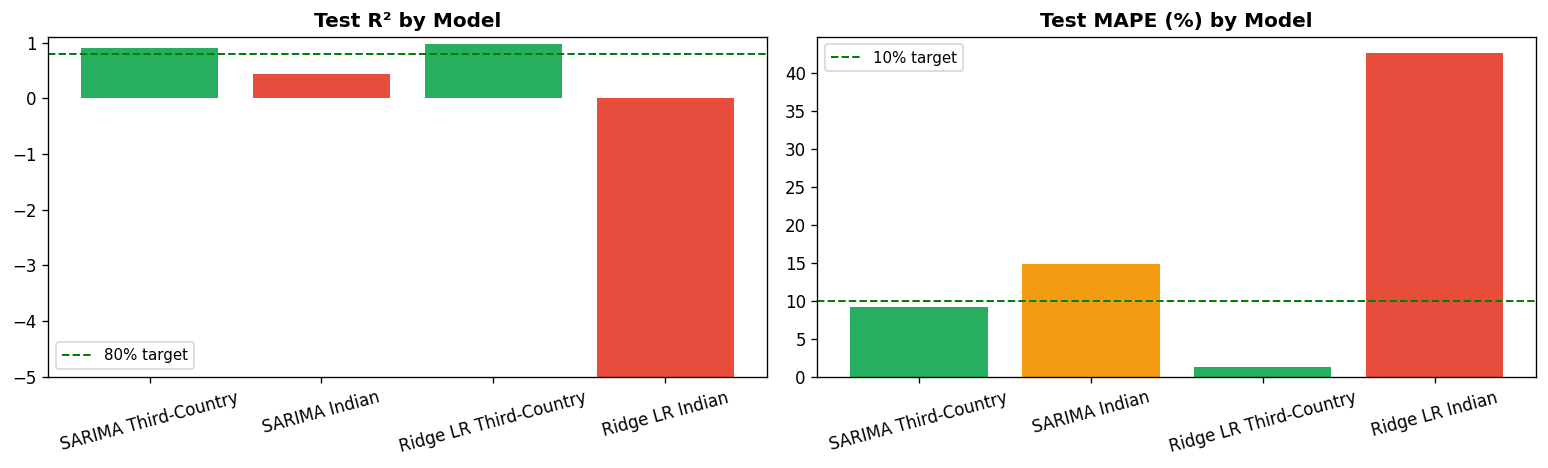

In [26]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

r2_colors = ['#27AE60' if r >= 0.8 else '#F39C12' if r >= 0.5
             else '#E74C3C' for r in summary_df['Test R²']]
axes[0].bar(summary_df['Model'], summary_df['Test R²'], color=r2_colors)
axes[0].axhline(0.8, color='green', linestyle='--', lw=1.2, label='80% target')
axes[0].set_title('Test R² by Model', fontweight='bold')
axes[0].set_ylim(-5, 1.1)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(fontsize=9)

mape_colors = ['#27AE60' if m <= 10 else '#F39C12' if m <= 20
               else '#E74C3C' for m in summary_df['Test MAPE']]
axes[1].bar(summary_df['Model'], summary_df['Test MAPE'], color=mape_colors)
axes[1].axhline(10, color='green', linestyle='--', lw=1.2, label='10% target')
axes[1].set_title('Test MAPE (%) by Model', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [27]:
# Aggregate metrics (exclude unreliable Indian LR)
reliable = [m3rd, mind, m3_test]
avg_r2   = np.mean([m['R²']       for m in reliable])
avg_mape = np.mean([m['MAPE (%)'] for m in reliable])
print(f'Avg R²   (3 reliable models) : {avg_r2:.4f}  (target ≥ 0.80)')
print(f'Avg MAPE (3 reliable models) : {avg_mape:.2f}%  (lower is better)')
print()
print('Key Findings:')
print('  • SARIMA Third-Country : captures Oct-Nov and Mar-Apr seasonal peaks')
print('  • Ridge LR Third-Country: Trekking arrivals + Lag1 are strongest predictors')
print('  • SARIMA Indian         : moderate after excluding COVID training years')
print('  • Ridge LR Indian       : structural break — post-COVID surge out-of-range')
print('  • Recommendation        : SARIMA for monthly; Ridge LR for annual 3rd-country only')

Avg R²   (3 reliable models) : 0.7685  (target ≥ 0.80)
Avg MAPE (3 reliable models) : 8.50%  (lower is better)

Key Findings:
  • SARIMA Third-Country : captures Oct-Nov and Mar-Apr seasonal peaks
  • Ridge LR Third-Country: Trekking arrivals + Lag1 are strongest predictors
  • SARIMA Indian         : moderate after excluding COVID training years
  • Ridge LR Indian       : structural break — post-COVID surge out-of-range
  • Recommendation        : SARIMA for monthly; Ridge LR for annual 3rd-country only


---
## 8. Tourism Insights Dashboard

Full visual overview of Nepal tourism trends (2010–2025).

In [28]:
# Data prep
sarima_d = sarima_df.copy()
sarima_d['Year']  = sarima_d.index.year
sarima_d['Month'] = sarima_d.index.month
lr3 = lr_3rd_df.copy()
lri = lr_ind_df.copy()

# ── KPIs ────────────────────────────────────────────────────────────────────
total_2019   = int(lr3[lr3['Year'] == 2019]['Total_Arrivals'].values[0])
total_2025   = int(lr3[lr3['Year'] == 2025]['Total_Arrivals'].values[0])
third_2025   = int(lr3[lr3['Year'] == 2025]['Third_Country_Arrivals'].values[0])
indian_2025  = int(lri[lri['Year'] == 2025]['Indian_Arrivals'].values[0])
income_2025  = float(lr3[lr3['Year'] == 2025]['Tourism_Income_USD_Mn'].values[0])
income_2019  = float(lr3[lr3['Year'] == 2019]['Tourism_Income_USD_Mn'].values[0])
recovery_pct = (total_2025 / total_2019) * 100

print('=== Key Performance Indicators (2025 vs 2019 Pre-COVID) ===')
print(f'  Total Arrivals 2025  : {total_2025:,}  ({(total_2025-total_2019)/total_2019*100:+.1f}% vs 2019)')
print(f'  Third-Country 2025   : {third_2025:,}  ({third_2025/total_2025*100:.1f}% of total)')
print(f'  Indian Arrivals 2025 : {indian_2025:,}  ({indian_2025/total_2025*100:.1f}% of total)')
print(f'  Tourism Income 2025  : USD {income_2025:.0f}M  ({(income_2025-income_2019)/income_2019*100:+.1f}% vs 2019)')
print(f'  COVID Recovery       : {recovery_pct:.1f}% of 2019 levels reached')

=== Key Performance Indicators (2025 vs 2019 Pre-COVID) ===
  Total Arrivals 2025  : 1,162,365  (-2.9% vs 2019)
  Third-Country 2025   : 868,981  (74.8% of total)
  Indian Arrivals 2025 : 293,384  (25.2% of total)
  Tourism Income 2025  : USD 298M  (-43.1% vs 2019)
  COVID Recovery       : 97.1% of 2019 levels reached


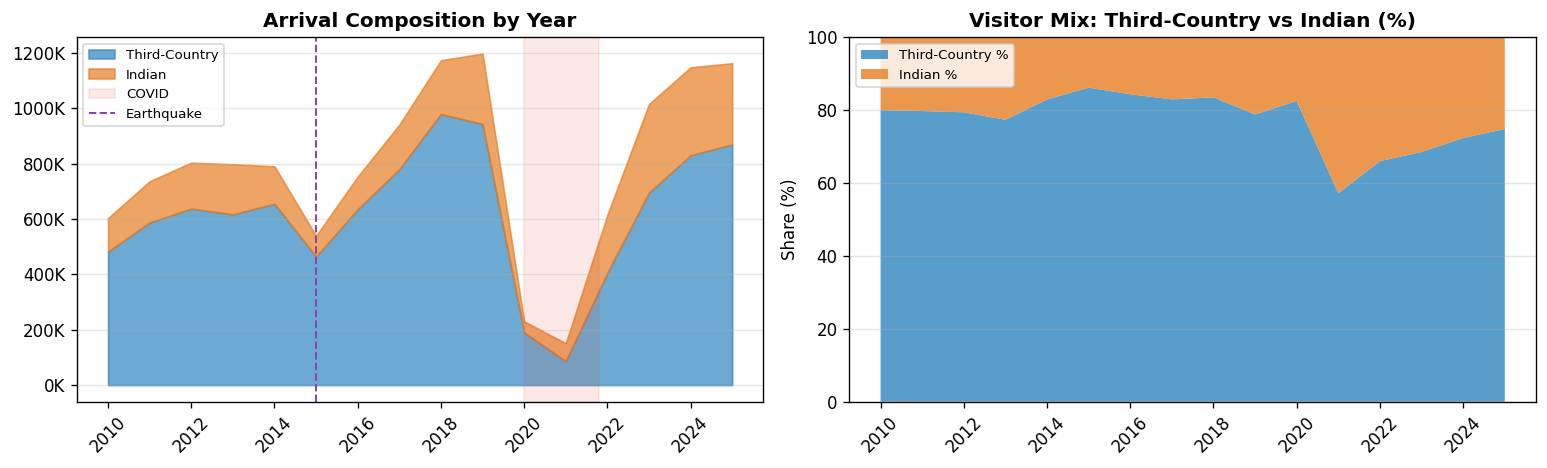

In [29]:
# ── Arrival composition + visitor mix ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].fill_between(lr3['Year'], lr3['Third_Country_Arrivals'],
                     color='#2E86C1', alpha=0.7, label='Third-Country')
axes[0].fill_between(lr3['Year'],
                     lr3['Third_Country_Arrivals'], lr3['Total_Arrivals'],
                     color='#E67E22', alpha=0.7, label='Indian')
axes[0].axvspan(2020, 2021.8, color='#E74C3C', alpha=0.12, label='COVID')
axes[0].axvline(2015, color='#8E44AD', linestyle='--', lw=1.2, label='Earthquake')
axes[0].set_title('Arrival Composition by Year', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
axes[0].set_xticks(range(2010, 2026, 2))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)

third_pct  = lr3['Third_Country_Arrivals'] / lr3['Total_Arrivals'] * 100
indian_pct = lri['Indian_Arrivals'] / lr3['Total_Arrivals'] * 100
axes[1].stackplot(lr3['Year'], third_pct, indian_pct,
                  labels=['Third-Country %', 'Indian %'],
                  colors=['#2E86C1', '#E67E22'], alpha=0.8)
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('Share (%)')
axes[1].set_title('Visitor Mix: Third-Country vs Indian (%)', fontweight='bold')
axes[1].set_xticks(range(2010, 2026, 2))
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=8, loc='upper left'); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

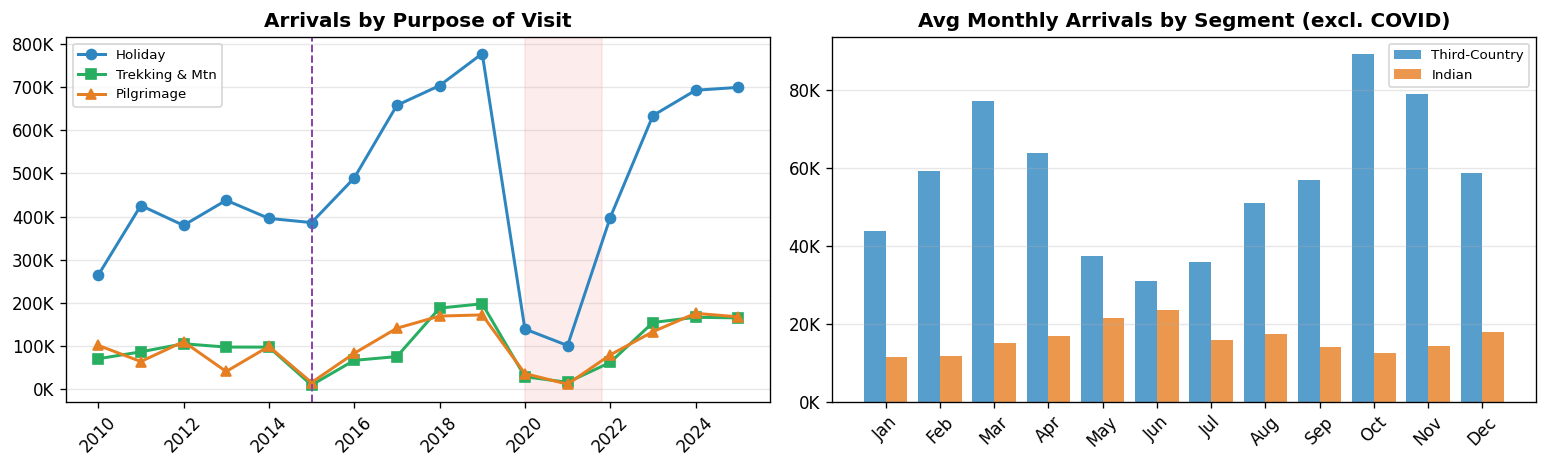

In [30]:
# ── Purpose of visit + seasonality ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(lr3['Year'], lr3['Holiday_Arrivals'],
             'o-', color='#2E86C1', lw=1.8, label='Holiday')
axes[0].plot(lr3['Year'], lr3['Trekking_Mtn_Arrivals'],
             's-', color='#27AE60', lw=1.8, label='Trekking & Mtn')
axes[0].plot(lr3['Year'], lr3['Pilgrimage_Arrivals'],
             '^-', color='#E67E22', lw=1.8, label='Pilgrimage')
axes[0].axvspan(2020, 2021.8, color='#E74C3C', alpha=0.1)
axes[0].axvline(2015, color='#8E44AD', linestyle='--', lw=1.2)
axes[0].set_title('Arrivals by Purpose of Visit', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
axes[0].set_xticks(range(2010, 2026, 2))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)

sea     = sarima_d[~sarima_d['Year'].isin([2020, 2021])]
avg_3rd = sea.groupby('Month')['Third_Country_Arrivals'].mean()
avg_ind = sea.groupby('Month')['Indian_Arrivals'].mean()
months_lbl = ['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Aug','Sep','Oct','Nov','Dec']
x = np.arange(12)
axes[1].bar(x - 0.2, avg_3rd.values, 0.4, color='#2E86C1', alpha=0.8, label='Third-Country')
axes[1].bar(x + 0.2, avg_ind.values, 0.4, color='#E67E22', alpha=0.8, label='Indian')
axes[1].set_xticks(x); axes[1].set_xticklabels(months_lbl, rotation=45)
axes[1].set_title('Avg Monthly Arrivals by Segment (excl. COVID)', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

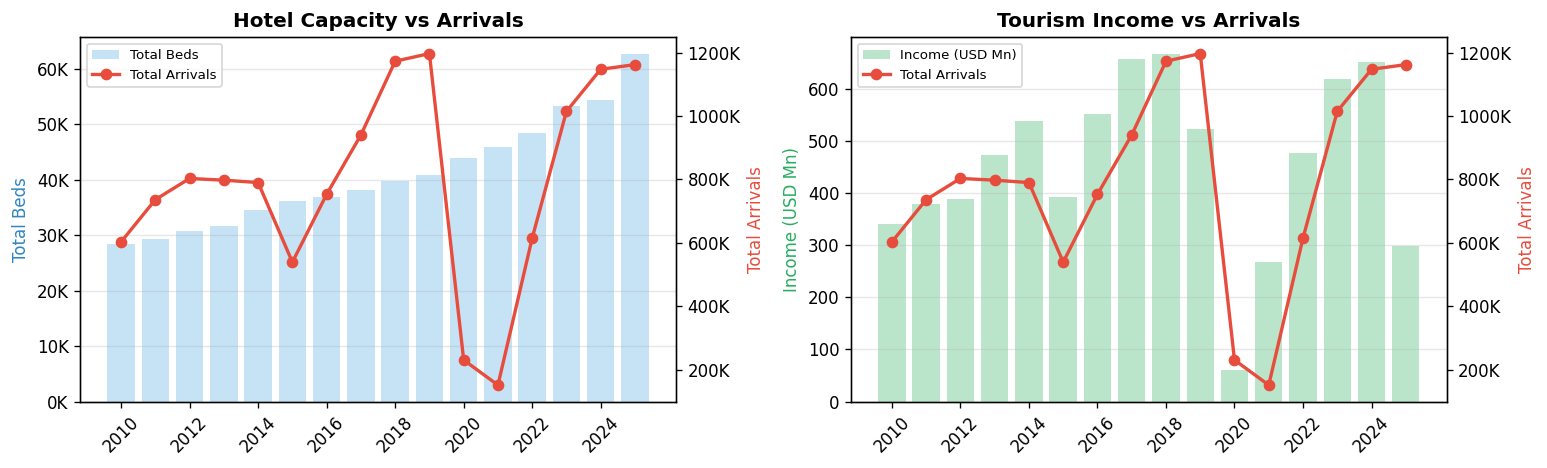

In [31]:
# ── Hotel supply + tourism income ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax2a = axes[0].twinx()
axes[0].bar(lr3['Year'], lr3['Total_Beds'], color='#AED6F1', alpha=0.7, label='Total Beds')
ax2a.plot(lr3['Year'], lr3['Total_Arrivals'], 'o-', color='#E74C3C', lw=2, label='Total Arrivals')
axes[0].set_ylabel('Total Beds', color='#2E86C1')
ax2a.set_ylabel('Total Arrivals', color='#E74C3C')
axes[0].set_title('Hotel Capacity vs Arrivals', fontweight='bold')
axes[0].set_xticks(range(2010, 2026, 2)); axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax2a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
lines1, labs1 = axes[0].get_legend_handles_labels()
lines2, labs2 = ax2a.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labs1 + labs2, fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

lr3_clean = lr3.dropna(subset=['Tourism_Income_USD_Mn'])
ax2b = axes[1].twinx()
axes[1].bar(lr3_clean['Year'], lr3_clean['Tourism_Income_USD_Mn'],
            color='#A9DFBF', alpha=0.8, label='Income (USD Mn)')
ax2b.plot(lr3_clean['Year'], lr3_clean['Total_Arrivals'],
          'o-', color='#E74C3C', lw=2, label='Total Arrivals')
axes[1].set_ylabel('Income (USD Mn)', color='#27AE60')
ax2b.set_ylabel('Total Arrivals', color='#E74C3C')
axes[1].set_title('Tourism Income vs Arrivals', fontweight='bold')
axes[1].set_xticks(range(2010, 2026, 2)); axes[1].tick_params(axis='x', rotation=45)
ax2b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
lines1, labs1 = axes[1].get_legend_handles_labels()
lines2, labs2 = ax2b.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labs1 + labs2, fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

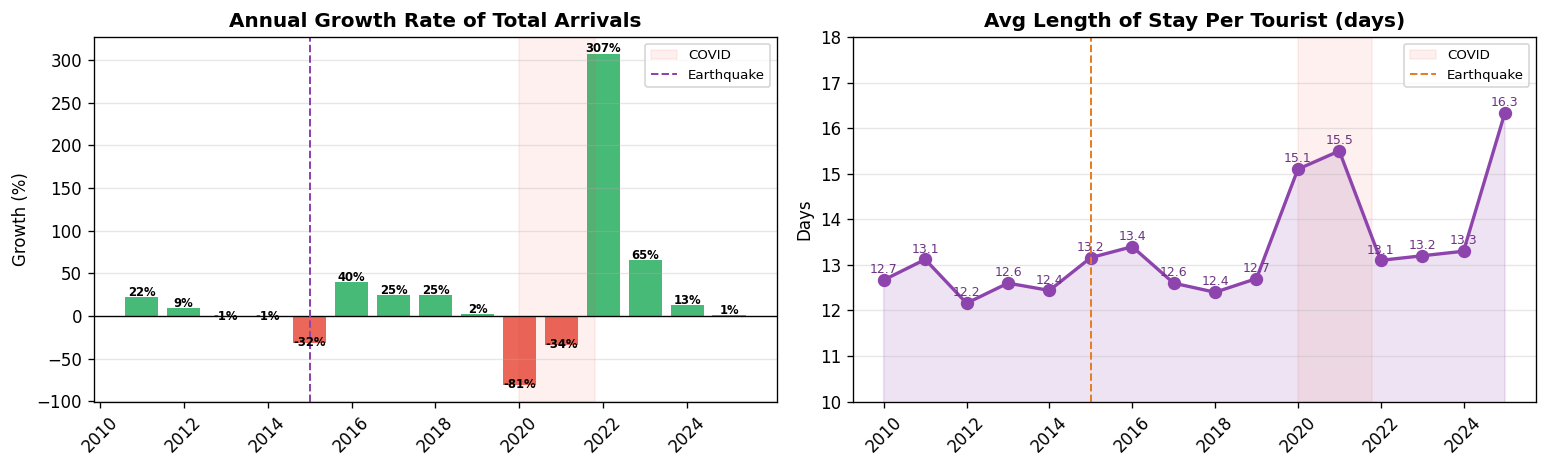

In [32]:
# ── YoY growth rate + avg length of stay ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

yoy = lr3['Total_Arrivals'].pct_change() * 100
colors_yoy = ['#27AE60' if v >= 0 else '#E74C3C' for v in yoy]
axes[0].bar(lr3['Year'], yoy, color=colors_yoy, alpha=0.85)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axvspan(2020, 2021.8, color='#E74C3C', alpha=0.08, label='COVID')
axes[0].axvline(2015, color='#8E44AD', linestyle='--', lw=1.2, label='Earthquake')
for yr, val in zip(lr3['Year'], yoy):
    if not pd.isna(val):
        axes[0].text(yr, val + (1.5 if val >= 0 else -3.5),
                     f'{val:.0f}%', ha='center', fontsize=7, fontweight='bold')
axes[0].set_title('Annual Growth Rate of Total Arrivals', fontweight='bold')
axes[0].set_ylabel('Growth (%)')
axes[0].set_xticks(range(2010, 2026, 2)); axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(lr3['Year'], lr3['Avg_Length_of_Stay'], 'o-', color='#8E44AD', lw=2, markersize=7)
axes[1].fill_between(lr3['Year'], lr3['Avg_Length_of_Stay'], alpha=0.15, color='#8E44AD')
for yr, val in zip(lr3['Year'], lr3['Avg_Length_of_Stay']):
    axes[1].text(yr, val + 0.15, f'{val:.1f}', ha='center', fontsize=7.5, color='#6C3483')
axes[1].axvspan(2020, 2021.8, color='#E74C3C', alpha=0.08, label='COVID')
axes[1].axvline(2015, color='#E67E22', linestyle='--', lw=1.2, label='Earthquake')
axes[1].set_title('Avg Length of Stay Per Tourist (days)', fontweight='bold')
axes[1].set_ylabel('Days')
axes[1].set_ylim(10, 18)
axes[1].set_xticks(range(2010, 2026, 2)); axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

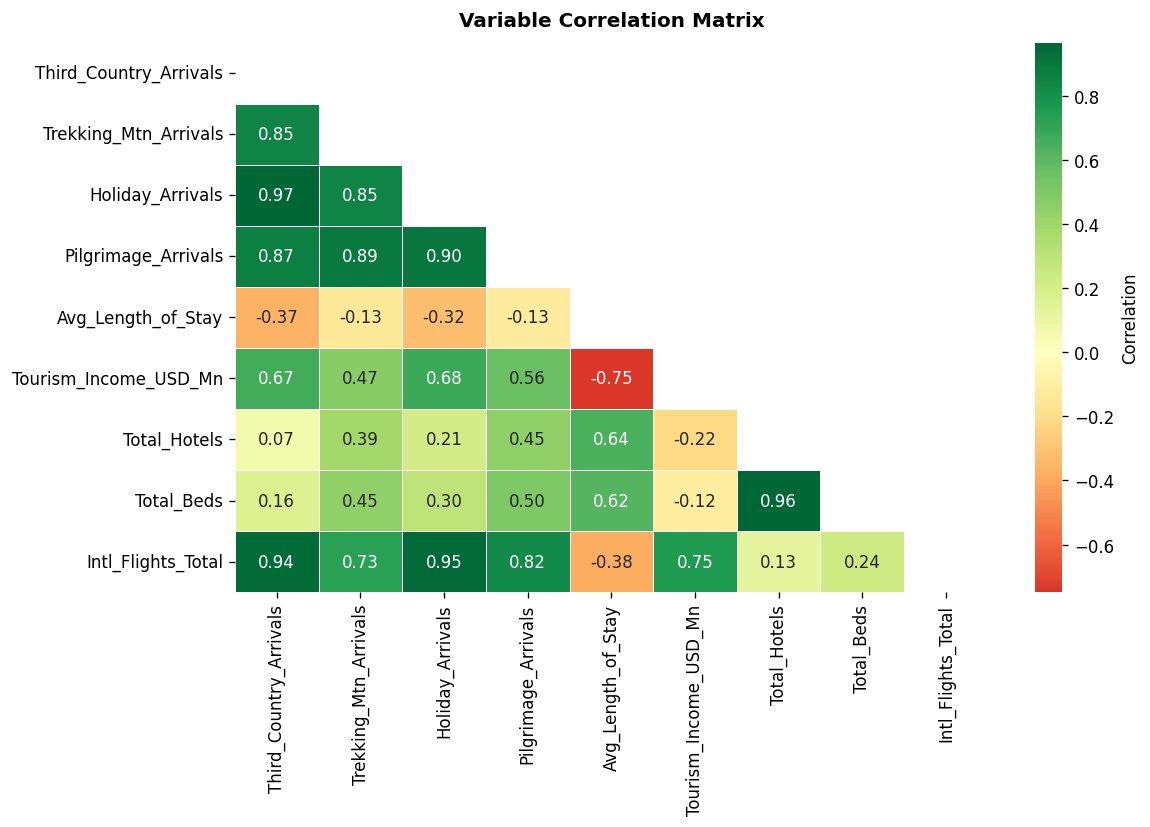

In [33]:
# ── Correlation heatmap ────────────────────────────────────────────────────────
corr_cols = [
    'Third_Country_Arrivals', 'Trekking_Mtn_Arrivals', 'Holiday_Arrivals',
    'Pilgrimage_Arrivals', 'Avg_Length_of_Stay', 'Tourism_Income_USD_Mn',
    'Total_Hotels', 'Total_Beds', 'Intl_Flights_Total'
]
corr_df = lr3[corr_cols].dropna().corr()

mask = np.zeros_like(corr_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, mask=mask,
            cbar_kws={'label': 'Correlation'})
ax.set_title('Variable Correlation Matrix', fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---
## 9. Key Takeaways

| Finding | Detail |
|---------|--------|
| Arrival Composition | Indian share grew from ~20% to ~33% post-COVID |
| Seasonality | Third-country peaks Oct–Nov and Mar–Apr (trekking seasons); Indian peaks May–Jun (pilgrimage/summer) |
| Purpose | Holiday is the largest category; Trekking drives third-country uniqueness |
| Hotel supply | Grown from 744 hotels (2010) to 1,578 (2025); arrivals more volatile |
| COVID impact | 2020 saw −83% arrivals drop and −88% income drop |
| Length of stay | Increased during COVID (fewer tourists, longer stays) and again in 2025 (16.3 days) |
| Multicollinearity | Income, Hotels, Beds all highly correlated with arrivals — motivates Ridge over OLS |
| Best model (monthly) | SARIMA Third-Country: R²≈0.90, MAPE≈9.22% |
| Best model (annual) | Ridge LR Third-Country: R²≈0.97, MAPE≈1.35% |
| Indian forecasting | Use SARIMA only; Ridge LR has post-COVID structural break |